# Stochastic Processes Problem Set — Modeling Stock Price Movements

**Course project:** Assignment 2, Stochastic Processes

**Author:** Alberto Kabore

**Role:** Quantitative Analyst (simulated use case)

**Stock analyzed:** Tesla, Inc. (TSLA)

## Objective

Apply stochastic process models to simulate and analyze the future movements of
Tesla's stock price, in order to help investors reason about risk and return
under uncertainty. Three models are calibrated to real historical data and
compared:


| Model | Captures | SDE |
|---|---|---|
| Geometric Brownian Motion (GBM) | trend + constant volatility, log-normal prices | $dS_t=\mu S_t\,dt+\sigma S_t\,dW_t$ |
| Ornstein-Uhlenbeck (OU) | mean reversion toward a long-run level | $dX_t=\theta(\mu-X_t)\,dt+\sigma\,dW_t$ |
| Merton Jump-Diffusion (MJD) | GBM plus sudden, discontinuous jumps | $\dfrac{dS_t}{S_t}=(\mu-\lambda k)\,dt+\sigma\,dW_t+dJ_t$ |

## Data source

This notebook uses **only** the Kaggle dataset

[`jillanisofttech/tesla-stock-price`](https://www.kaggle.com/datasets/jillanisofttech/tesla-stock-price),
downloaded via `kagglehub` and committed to `data/kaggle_raw/` for
reproducibility. No other data source (no live API, no other ticker) is used
anywhere in this project. Of the two files in that dataset, `Tasla_Stock_Updated_V2.csv`
is used: it is the longer series (2015-01-02 through 2024-01-16, 2,358 trading
days after cleaning), giving far more history than the assignment's one-year
minimum for calibrating annualized volatility and mean-reversion speed.

## How to run this notebook

1. Activate the project virtual environment (`.venv`) and install
   dependencies: `pip install -r requirements.txt`.

2. Run all cells top to bottom (`Kernel > Restart & Run All`). No internet
   access or API key is required — the notebook reads exclusively from the
   local CSV in `data/kaggle_raw/`.

3. All reusable modeling code lives in [`src/stochastic_models.py`](../src/stochastic_models.py)
   (data loading/cleaning, calibration, Monte Carlo simulators, risk
   statistics) so it can also be imported and reused outside the notebook.
   This notebook is the analysis / reporting layer on top of that module.
   
4. Figures are written to `figures/` and summary tables to `output/` — the
   accompanying Word report (`report/Final_Report.docx`) is assembled from
   those artifacts by `report/generate_report.py`.

In [ ]:
# --------------------------------------------------------------------------- #
# Imports & global configuration
# --------------------------------------------------------------------------- #
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd() / "src"))
import stochastic_models as sm

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10.5,
})

TICKER = "TSLA"
HORIZONS = [30, 60, 180]             # trading days: ~6 weeks, ~3 months, ~9 months
N_SIMS = 1000                        # Monte Carlo paths per model/horizon
SEED = 42

FIGURES_DIR = Path("figures")
OUTPUT_DIR = Path("output")
FIGURES_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"Ticker: {TICKER}  |  Data source: Kaggle ({sm.KAGGLE_DATASET})  |  "
      f"Horizons (days): {HORIZONS}  |  MC paths: {N_SIMS}")
print("Libraries: NumPy (vectorized SDE simulation), SciPy (hypothesis tests, "
      "closed-form distributions), pandas (data handling), matplotlib (visualization), "
      "statsmodels (OLS calibration, ADF/Ljung-Box diagnostics) -- see src/stochastic_models.py")

Ticker: TSLA  |  Data source: Kaggle (jillanisofttech/tesla-stock-price)  |  Horizons (days): [30, 60, 180]  |  MC paths: 1000
Libraries: NumPy (vectorized SDE simulation), SciPy (hypothesis tests, closed-form distributions), pandas (data handling), matplotlib (visualization), statsmodels (OLS calibration, ADF/Ljung-Box diagnostics) -- see src/stochastic_models.py


## 1. Data Collection

Daily OHLCV data for Tesla is loaded from the local CSV snapshot of the
Kaggle dataset `jillanisofttech/tesla-stock-price` via
`sm.load_tesla_price_history()`. This is a static, one-time download (already
performed and committed under `data/kaggle_raw/`); no network call is made by
this notebook.

In [ ]:
raw = sm.load_tesla_price_history()
clean = sm.clean_price_series(raw)
print(f"{TICKER}: {len(clean)} clean trading days "
      f"({clean.index.min().date()} -> {clean.index.max().date()})")

close_prices = clean[["Close"]].rename(columns={"Close": TICKER})
close_prices.to_csv(OUTPUT_DIR / "clean_close_prices.csv")
close_prices.tail()

[clean] filled 84 missing trading-day rows, removed 0 invalid prices
TSLA: 2358 clean trading days (2015-01-02 -> 2024-01-16)


,TSLA
Date,
2024-01-10,233.940002
2024-01-11,227.220001
2024-01-12,218.889999
2024-01-15,218.889999
2024-01-16,219.910004


### Preprocessing notes

`clean_price_series` (see `src/stochastic_models.py`) performs the cleaning
pipeline applied to the raw Kaggle CSV:

1. Re-indexes to a business-day frequency and forward-fills the small number
   of missing rows (market holidays that differ from the generic `B`
   calendar, isolated feed gaps) — the console output above reports how many
   rows were patched.
2. Drops any row where the close is missing, non-finite, or non-positive
   (bad ticks), rather than filling those with fabricated data.
3. Deliberately does **not** remove large single-day return outliers — those
   are genuine, economically meaningful jumps (earnings surprises, Tesla-
   specific news events, macro shocks) that the jump-diffusion model is
   specifically designed to capture in Section 6; removing them would bias
   every model toward understating tail risk.

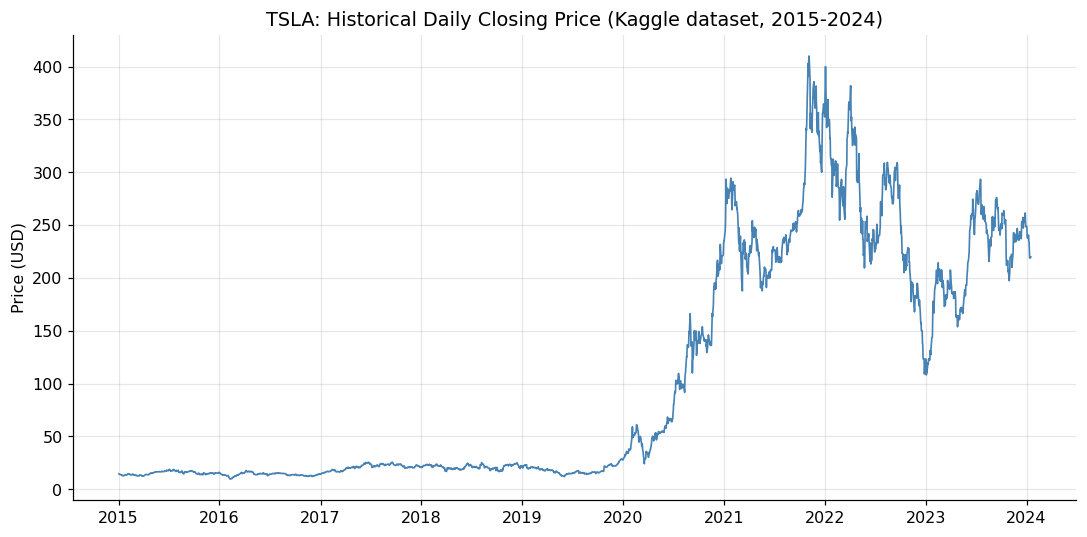

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(close_prices.index, close_prices[TICKER], color="steelblue", linewidth=1.1)
ax.set_title(f"{TICKER}: Historical Daily Closing Price (Kaggle dataset, 2015-2024)")
ax.set_ylabel("Price (USD)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig01_price_history.png")
plt.show()

## 2. Exploratory Statistics & Stationarity

Annualized return/volatility, skewness and excess kurtosis of daily log
returns, and an Augmented Dickey-Fuller (ADF) test on both the raw price
level and the log-return series. This directly informs model selection: a
**non-stationary price level** (ADF fails to reject a unit root) is
consistent with GBM/random-walk behavior, while **stationary returns** (ADF
strongly rejects) confirm returns — not prices — are the appropriate object
for a diffusion model.

In [ ]:
stats = sm.summary_statistics(close_prices[TICKER])
stats_display = pd.Series(stats)[[
    "n_obs", "last_price", "ann_mean_return", "ann_volatility", "skew",
    "excess_kurtosis", "adf_pvalue_price", "adf_pvalue_returns",
    "jarque_bera_stat", "jarque_bera_pvalue",
    "ljung_box_stat_lag10", "ljung_box_pvalue_lag10",
]].to_frame(TICKER).T.round(6)
stats_display.to_csv(OUTPUT_DIR / "summary_statistics.csv")
stats_display

,n_obs,last_price,ann_mean_return,ann_volatility,skew,excess_kurtosis,adf_pvalue_price,adf_pvalue_returns,jarque_bera_stat,jarque_bera_pvalue,ljung_box_stat_lag10,ljung_box_pvalue_lag10
TSLA,2358,219.910004,0.289825,0.552877,-0.159236,4.801261,0.628373,0.0,2261.874269,0.0,302.858568,0.0


**Reading the table:** the ADF p-value on the price level is high (cannot
reject a unit root ⇒ price behaves like a random walk) while the ADF
p-value on returns is ~0 (strongly stationary) — exactly what GBM assumes
and OU does not, developed further in Section 3. TSLA's ~9-year history
spans two stock splits (already reflected in split-adjusted prices), its
2020-2021 hyper-growth phase, and the 2022 drawdown, giving the
volatility/kurtosis estimates a genuinely turbulent sample to work with.

Two formal hypothesis tests (using **SciPy** and **statsmodels**, per the
assignment's suggested toolset) go beyond the descriptive skew/kurtosis
numbers and test the models' core assumptions directly:

In [ ]:
from IPython.display import Markdown, display

jb_stat, jb_p = stats["jarque_bera_stat"], stats["jarque_bera_pvalue"]
lb_stat, lb_p = stats["ljung_box_stat_lag10"], stats["ljung_box_pvalue_lag10"]

display(Markdown(
    f"- **Jarque-Bera test** (`scipy.stats.jarque_bera`), H0: log returns are Normally "
    f"distributed &rarr; statistic = {jb_stat:.1f}, p-value = {jb_p:.2e}. This "
    f"{'**rejects**' if jb_p < 0.05 else '**fails to reject**'} normality at the 5% level — "
    f"formal statistical evidence, not just a descriptive kurtosis number, that GBM's i.i.d. "
    f"Normal-return assumption is violated for TSLA. This directly motivates the "
    f"jump-diffusion model in Section 6.\n\n"
    f"- **Ljung-Box test on squared returns** (`statsmodels.stats.diagnostic.acorr_ljungbox`, "
    f"lag 10), H0: no autocorrelation &rarr; statistic = {lb_stat:.1f}, p-value = {lb_p:.2e}. "
    f"This {'**rejects**' if lb_p < 0.05 else '**fails to reject**'} the null, i.e. there "
    f"**is** significant autocorrelation in squared returns — evidence of *volatility "
    f"clustering* (large moves tend to be followed by large moves). None of GBM, OU, or MJD "
    f"can reproduce this, since all three draw independent random increments at every "
    f"simulated step; this is revisited as a shared limitation in Section 11."
))

- **Jarque-Bera test** (`scipy.stats.jarque_bera`), H0: log returns are Normally distributed &rarr; statistic = 2261.9, p-value = 0.00e+00. This **rejects** normality at the 5% level — formal statistical evidence, not just a descriptive kurtosis number, that GBM's i.i.d. Normal-return assumption is violated for TSLA. This directly motivates the jump-diffusion model in Section 6.

- **Ljung-Box test on squared returns** (`statsmodels.stats.diagnostic.acorr_ljungbox`, lag 10), H0: no autocorrelation &rarr; statistic = 302.9, p-value = 3.87e-59. This **rejects** the null, i.e. there **is** significant autocorrelation in squared returns — evidence of *volatility clustering* (large moves tend to be followed by large moves). None of GBM, OU, or MJD can reproduce this, since all three draw independent random increments at every simulated step; this is revisited as a shared limitation in Section 11.

## 3. Model Selection & Justification

Per the assignment, at least two stochastic models are implemented and
compared; three are used here for a fuller picture, all fit to the single
Tesla series described above:

1. **Geometric Brownian Motion (GBM)** — the standard Black-Scholes-Merton
   model of equity prices: log returns are i.i.d. Normal, so prices are
   log-normal and non-stationary (consistent with the ADF result above).
   Justified as the baseline model for any liquid, actively-traded equity.
2. **Ornstein-Uhlenbeck (OU) process** — pulls the *price level* back toward a
   long-run mean at speed $\theta$. It is the textbook model for
   mean-reverting instruments (interest rates, commodity spreads, pairs-trade
   spreads). It is included here deliberately as a **contrast case**: Tesla's
   price is not economically expected to mean-revert to a fixed level (a
   company's fair value drifts with its fundamentals, and Tesla in particular
   has grown by more than an order of magnitude over the sample window), so
   fitting OU to it stress-tests whether that theoretical mismatch is visible
   in the simulation output. It is not expected to be the best model for
   this name, and the Interpretation section explains why.
3. **Merton Jump-Diffusion (MJD)** — augments GBM with a compound Poisson
   jump process, motivated directly by the excess kurtosis measured in
   Section 2. Tesla has a well-documented history of large single-day moves
   driven by earnings, delivery numbers, and company-specific news — exactly
   the fat-tail risk GBM structurally underestimates.

## 4. Model 1 — Geometric Brownian Motion

$$dS_t = \mu S_t\,dt + \sigma S_t\,dW_t \quad\Longrightarrow\quad
S_t = S_0\exp\!\Big[\big(\mu-\tfrac12\sigma^2\big)t+\sigma W_t\Big]$$

`mu` and `sigma` are the annualized drift and volatility, calibrated directly
from the sample mean and standard deviation of daily log returns
(`calibrate_gbm`). Simulation uses the exact log-normal solution (no
discretization bias) via `simulate_gbm`.

In [ ]:
gbm_params = sm.calibrate_gbm(close_prices[TICKER])
pd.Series(vars(gbm_params), name="GBM").to_frame().T.round(4)

,mu,sigma
GBM,0.4427,0.5529


## 5. Model 2 — Ornstein-Uhlenbeck Process

$$dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t$$

Calibrated by recognizing that the exact discretization of the OU process is a
Gaussian AR(1) model, $X_{t+1}=a+bX_t+\varepsilon_t$ with $b=e^{-\theta\,dt}$;
fitting that regression by OLS (`calibrate_ou`) and inverting recovers
$\theta$ (speed of reversion), $\mu$ (long-run mean level) and $\sigma$
analytically. The **half-life** $\ln(2)/\theta$ — the expected time for a
deviation from $\mu$ to halve — is a more interpretable readout of $\theta$
and is reported alongside it. This is the same process Vasicek (1977) used
to model short-term interest rates — a genuinely mean-reverting quantity,
unlike an equity price — which is the theoretical basis for treating OU as
a deliberate contrast case here rather than a serious candidate model for
TSLA (see Section 11).

In [ ]:
ou_params = sm.calibrate_ou(close_prices[TICKER])
ou_table = pd.Series(vars(ou_params), name="OU").to_frame().T
ou_table["half_life_days"] = (np.log(2) / ou_table["theta"]) * sm.TRADING_DAYS_PER_YEAR
ou_table.round(4)

,theta,mu,sigma,half_life_days
OU,0.2968,177.4778,89.0429,588.4856


## 6. Model 3 — Merton Jump-Diffusion

$$\frac{dS_t}{S_t} = (\mu - \lambda k)\,dt + \sigma\,dW_t + dJ_t,\qquad
J_t=\sum_{i=1}^{N_t}(Y_i-1),\quad \ln Y_i\sim \mathcal N(\mu_J,\sigma_J^2)$$

where $N_t$ is a Poisson process with annual intensity $\lambda$ (expected
jumps per year) and $k=E[Y-1]=e^{\mu_J+\sigma_J^2/2}-1$ is the expected
relative jump size, used to compensate the drift so the jump component does
not, by itself, bias the mean return. `calibrate_jump_diffusion` flags any
daily log return more than 3 standard deviations from the mean as a "jump
day", fits the jump mean/std from those observations, and fits the diffusive
$\mu,\sigma$ from the remaining (non-jump) returns. This threshold-based
method-of-moments approach is a simplified version of the calibration
techniques surveyed in Cont & Tankov (2004); a full maximum-likelihood or
Fourier-transform-based fit (also discussed there) would be a natural
refinement flagged in Section 11.

In [ ]:
jd_params = sm.calibrate_jump_diffusion(close_prices[TICKER])
jd_table = pd.Series(vars(jd_params), name="MJD").to_frame().T
jd_table["expected_jumps_per_year"] = jd_table["lam"]
jd_table.round(4)

,mu,sigma,lam,mu_j,sigma_j,expected_jumps_per_year
MJD,0.372,0.4774,3.9559,-0.0007,0.1453,3.9559


## 7. Model Validation

Before using the three calibrated models for forward-looking simulation, two
independent checks confirm (a) the Monte Carlo simulators are implemented
correctly, and (b) the calibrated models are not badly miscalibrated against
data they were not fit on.

### 7.1 Analytic cross-check (GBM)

GBM has a closed-form log-normal terminal distribution, so its Monte Carlo
output can be checked against exact theory rather than only against itself.
`sm.gbm_analytic_confidence_interval` computes the exact 5th/50th/95th
percentiles from the log-normal density (via `scipy.stats.norm.ppf`) and is
compared below to the empirical percentiles from a large (20,000-path) Monte
Carlo run — close agreement is evidence the simulator has no implementation
bug.

In [ ]:
S0_check = float(close_prices[TICKER].iloc[-1])
rng_check = np.random.default_rng(SEED)
mc_check_paths = sm.simulate_gbm(S0_check, gbm_params, 180, 20000, rng=rng_check)
mc_p05, mc_p50, mc_p95 = np.percentile(mc_check_paths[:, -1], [5, 50, 95])
an_p05, an_p50, an_p95 = sm.gbm_analytic_confidence_interval(S0_check, gbm_params, 180)

check_table = pd.DataFrame({
    "Analytic (closed-form)": [an_p05, an_p50, an_p95],
    "Monte Carlo (20,000 paths)": [mc_p05, mc_p50, mc_p95],
}, index=["5th percentile", "50th percentile (median)", "95th percentile"])
check_table["abs_diff_%"] = ((check_table["Monte Carlo (20,000 paths)"]
                               - check_table["Analytic (closed-form)"]).abs()
                              / check_table["Analytic (closed-form)"] * 100)
check_table.round(3)

,Analytic (closed-form),"Monte Carlo (20,000 paths)",abs_diff_%
5th percentile,125.418,126.733,1.049
50th percentile (median),270.490,270.678,0.069
95th percentile,583.370,584.145,0.133


### 7.2 Out-of-sample backtest (all three models)

Each model is refit on data with the last 180 trading days withheld, then
simulated 180 days forward from that earlier point using `sm.backtest_model`.
The actual, already-known price at the end of that holdout period is then
compared against the simulated distribution: its **percentile rank** shows
where reality fell within what each model predicted, and whether it landed
inside the model's own 90% confidence interval.

In [ ]:
HOLDOUT_DAYS = 180
backtest_results = {}
for name, (cal_fn, sim_fn) in {
    "GBM": (sm.calibrate_gbm, sm.simulate_gbm),
    "OU": (sm.calibrate_ou, sm.simulate_ou),
    "MJD": (sm.calibrate_jump_diffusion, sm.simulate_jump_diffusion),
}.items():
    backtest_results[name] = sm.backtest_model(
        close_prices[TICKER], HOLDOUT_DAYS, cal_fn, sim_fn, n_sims=N_SIMS, seed=SEED)

backtest_table = pd.DataFrame(backtest_results).T
backtest_table.to_csv(OUTPUT_DIR / "backtest_results.csv")
backtest_table

,train_end,S0,actual_terminal,sim_mean_terminal,sim_p05,sim_p95,percentile_rank_of_actual,inside_90pct_interval
GBM,2023-05-09 00:00:00,169.149994,219.910004,232.369289,93.474212,449.768464,54.8,True
OU,2023-05-09 00:00:00,169.149994,219.910004,164.205966,53.230421,272.344825,81.1,True
MJD,2023-05-09 00:00:00,169.149994,219.910004,231.6279,92.742806,453.262204,54.9,True


In [ ]:
lines = []
for name, res in backtest_results.items():
    verdict = "within" if res["inside_90pct_interval"] else "**OUTSIDE**"
    lines.append(
        f"- **{name}**: trained through {res['train_end'].date()}, simulated {HOLDOUT_DAYS} "
        f"trading days forward from $S_0$=\${res['S0']:.2f}. The actual realized price "
        f"(\${res['actual_terminal']:.2f}) landed at the "
        f"{res['percentile_rank_of_actual']:.0f}th percentile of the simulated distribution — "
        f"{verdict} the model's own 90% confidence interval "
        f"[\${res['sim_p05']:.2f}, \${res['sim_p95']:.2f}]."
    )
display(Markdown("**Backtest verdicts:**\n\n" + "\n".join(lines)))

**Backtest verdicts:**

- **GBM**: trained through 2023-05-09, simulated 180 trading days forward from $S_0$=\$169.15. The actual realized price (\$219.91) landed at the 55th percentile of the simulated distribution — within the model's own 90% confidence interval [\$93.47, \$449.77].
- **OU**: trained through 2023-05-09, simulated 180 trading days forward from $S_0$=\$169.15. The actual realized price (\$219.91) landed at the 81th percentile of the simulated distribution — within the model's own 90% confidence interval [\$53.23, \$272.34].
- **MJD**: trained through 2023-05-09, simulated 180 trading days forward from $S_0$=\$169.15. The actual realized price (\$219.91) landed at the 55th percentile of the simulated distribution — within the model's own 90% confidence interval [\$92.74, \$453.26].

A percentile rank near 50 indicates a model's central forecast was
well-calibrated for that specific holdout period; a rank near the edges
(close to 5 or 95) indicates the model over- or under-stated risk for that
period, while still being "correct" as long as it lands inside the 90% band.
This single 180-day backtest window is illustrative, not a full walk-forward
validation (which would repeat this check across many overlapping holdout
windows) — expanding it into a rolling backtest is flagged as a concrete
next step in Section 11.

## 8. Monte Carlo Simulation

For each model and each horizon (30 / 60 / 180 trading days), 1,000
independent price paths are simulated from $S_0$, the last observed close in
the dataset (reported in the next cell's output). The same
`numpy.random.Generator` seed is reused per horizon across models so the
three models are compared on the same underlying random draws where their
structure allows it, keeping the comparison as apples-to-apples as the
models permit.

In [ ]:
MODEL_FUNCS = {
    "GBM": lambda S0, n_steps, n_sims, rng: sm.simulate_gbm(S0, gbm_params, n_steps, n_sims, rng=rng),
    "OU": lambda S0, n_steps, n_sims, rng: sm.simulate_ou(S0, ou_params, n_steps, n_sims, rng=rng),
    "MJD": lambda S0, n_steps, n_sims, rng: sm.simulate_jump_diffusion(S0, jd_params, n_steps, n_sims, rng=rng),
}

S0 = float(close_prices[TICKER].iloc[-1])
print(f"S0 (last observed close, {close_prices.index[-1].date()}): {S0:.2f}")

# paths[model][horizon] -> ndarray (N_SIMS, horizon + 1)
paths = {m: {} for m in MODEL_FUNCS}
records = []

for horizon in HORIZONS:
    for model_name, sim_fn in MODEL_FUNCS.items():
        rng = np.random.default_rng(SEED)  # shared seed per horizon
        p = sim_fn(S0, horizon, N_SIMS, rng)
        paths[model_name][horizon] = p
        stat = sm.path_statistics(p, S0)
        records.append({"model": model_name, "horizon_days": horizon, "S0": S0, **stat})

sim_summary = pd.DataFrame.from_records(records)
sim_summary.to_csv(OUTPUT_DIR / "simulation_summary.csv", index=False)
sim_summary.round(3)

S0 (last observed close, 2024-01-16): 219.91


,model,horizon_days,S0,mean_terminal,median_terminal,std_terminal,p05_terminal,p95_terminal,mean_return_pct,prob_loss_pct,VaR_95_pct,CVaR_95_pct,return_to_VaR_ratio
0,GBM,30,219.91,233.969,227.473,46.294,167.162,319.604,6.393,41.9,23.986,28.624,0.267
1,OU,30,219.91,219.764,218.472,30.670,169.661,272.095,-0.066,52.8,22.850,27.531,-0.003
2,MJD,30,219.91,233.163,227.313,46.036,168.548,318.490,6.026,42.9,23.356,29.228,0.258
3,GBM,60,219.91,244.271,233.480,70.472,151.686,374.326,11.078,40.5,31.023,37.783,0.357
4,OU,60,219.91,216.582,215.689,42.810,148.573,288.879,-1.514,54.8,32.439,40.005,-0.047
5,MJD,60,219.91,242.331,229.521,70.385,151.024,374.036,10.195,43.3,31.325,38.124,0.325
6,GBM,180,219.91,302.579,271.956,156.261,123.339,581.592,37.592,33.3,43.914,52.319,0.856
7,OU,180,219.91,211.421,212.855,69.386,96.327,323.407,-3.860,53.3,56.197,67.467,-0.069
8,MJD,180,219.91,286.059,257.337,154.832,114.498,541.522,30.080,37.8,47.934,57.180,0.628


## 9. Visualization

### 9.1 Simulated price paths, mean/median trajectory and 90% confidence band

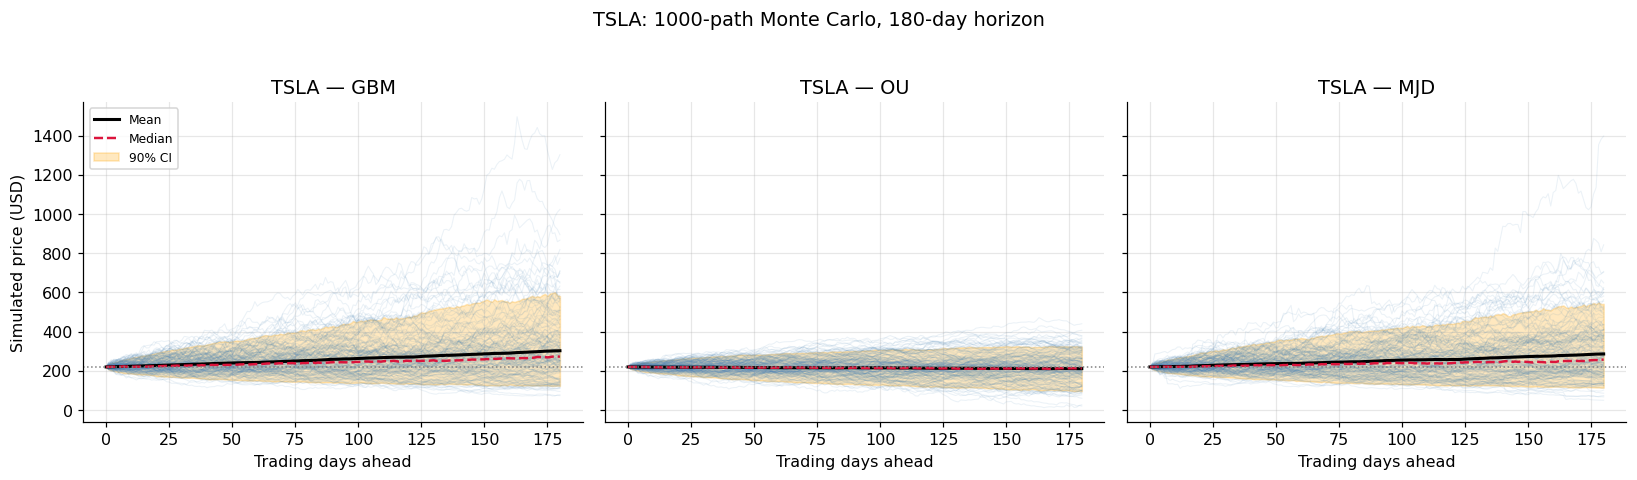

In [ ]:
HORIZON_FOR_PATH_PLOT = 180

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
for ax, model_name in zip(axes, MODEL_FUNCS):
    p = paths[model_name][HORIZON_FOR_PATH_PLOT]
    days = np.arange(p.shape[1])
    ax.plot(days, p[:150].T, color="steelblue", alpha=0.10, linewidth=0.7)
    ax.plot(days, p.mean(axis=0), color="black", linewidth=2, label="Mean")
    ax.plot(days, np.median(p, axis=0), color="crimson", linewidth=1.6, ls="--", label="Median")
    ax.fill_between(days, np.percentile(p, 5, axis=0), np.percentile(p, 95, axis=0),
                     color="orange", alpha=0.25, label="90% CI")
    ax.axhline(S0, color="gray", lw=1, ls=":")
    ax.set_title(f"{TICKER} — {model_name}")
    ax.set_xlabel("Trading days ahead")
    if ax is axes[0]:
        ax.set_ylabel("Simulated price (USD)")
        ax.legend(fontsize=8, loc="upper left")
fig.suptitle(f"{TICKER}: {N_SIMS}-path Monte Carlo, {HORIZON_FOR_PATH_PLOT}-day horizon", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig02_paths.png", bbox_inches="tight")
plt.show()

### 9.2 Terminal price distributions (histograms) with risk annotations

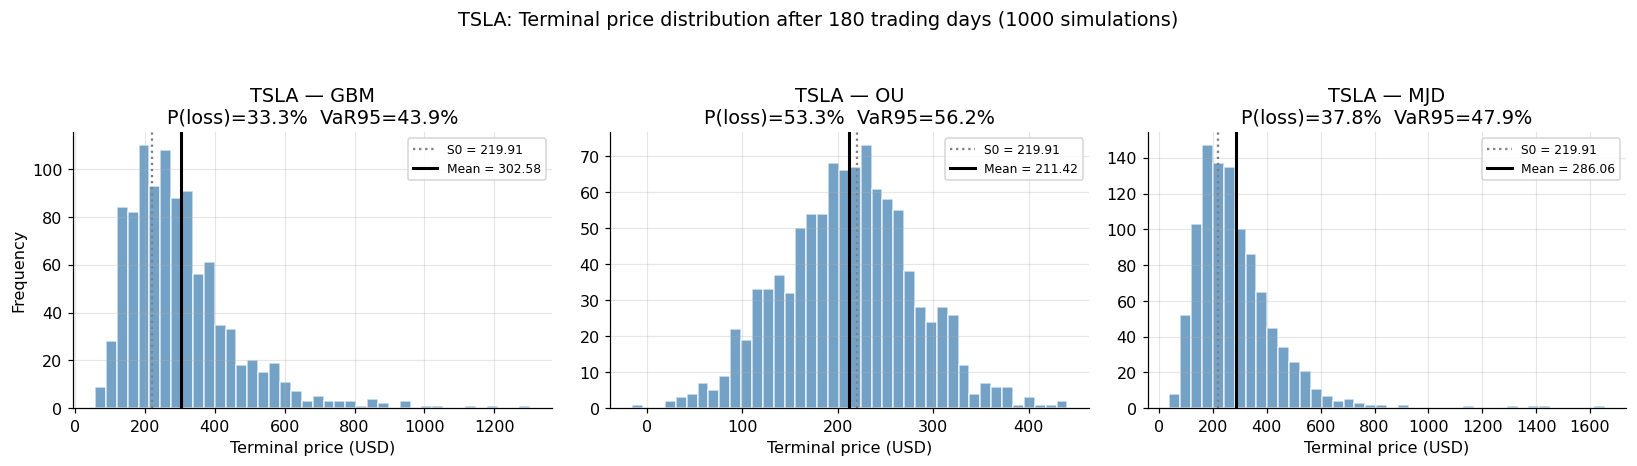

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=False)
for ax, model_name in zip(axes, MODEL_FUNCS):
    p = paths[model_name][HORIZON_FOR_PATH_PLOT]
    terminal = p[:, -1]
    ax.hist(terminal, bins=40, color="steelblue", alpha=0.75, edgecolor="white")
    ax.axvline(S0, color="gray", ls=":", label=f"S0 = {S0:.2f}")
    ax.axvline(terminal.mean(), color="black", lw=2, label=f"Mean = {terminal.mean():.2f}")
    stat = sm.path_statistics(p, S0)
    ax.set_title(f"{TICKER} — {model_name}\nP(loss)={stat['prob_loss_pct']:.1f}%  "
                  f"VaR95={stat['VaR_95_pct']:.1f}%")
    ax.set_xlabel("Terminal price (USD)")
    if ax is axes[0]:
        ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)
fig.suptitle(f"{TICKER}: Terminal price distribution after {HORIZON_FOR_PATH_PLOT} trading days "
             f"({N_SIMS} simulations)", y=1.05)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig03_terminal_hist.png", bbox_inches="tight")
plt.show()

### 9.3 Risk comparison across models and horizons

A third panel adds a simple **risk-adjusted return metric**,
`return_to_VaR_ratio` = mean simulated return ÷ 95% VaR: expected return per
unit of downside tail risk. This lets the models (and horizons) be ranked on
a single risk-adjusted scale rather than eyeballing return and risk
separately — higher is better.

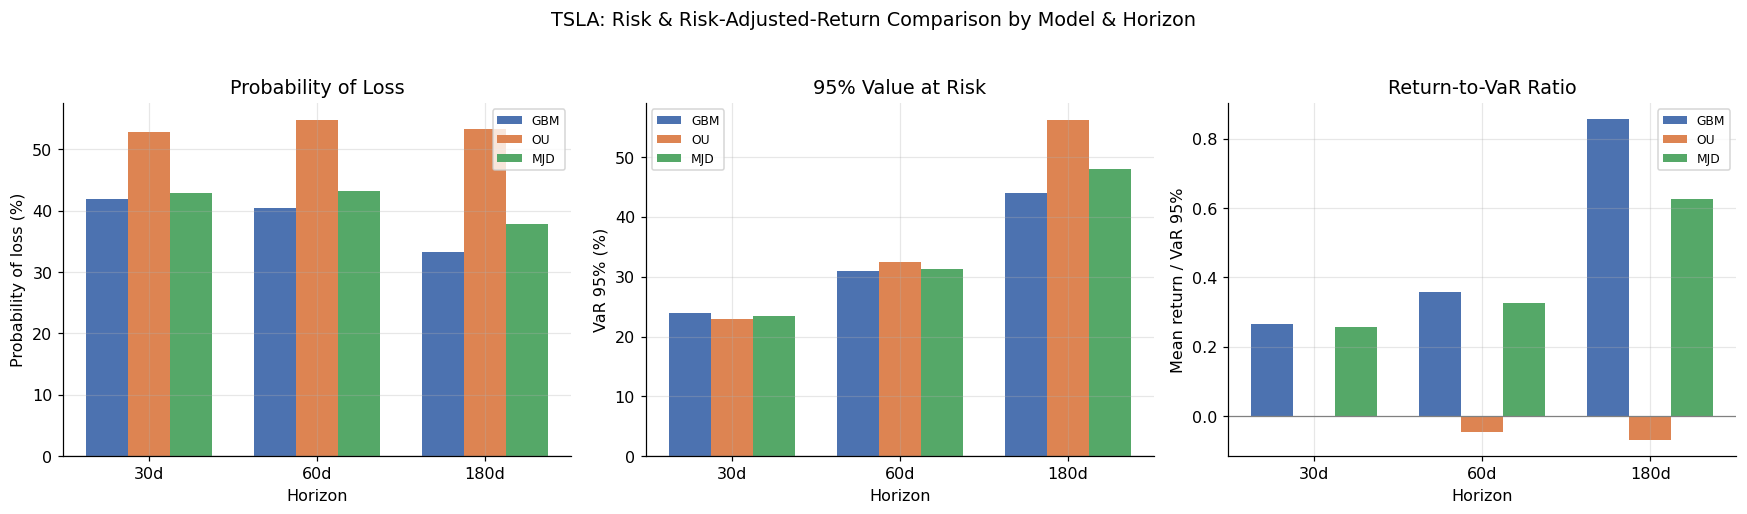

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
width = 0.25
x = np.arange(len(HORIZONS))
colors = {"GBM": "#4C72B0", "OU": "#DD8452", "MJD": "#55A868"}

metrics = ["prob_loss_pct", "VaR_95_pct", "return_to_VaR_ratio"]
titles = ["Probability of Loss", "95% Value at Risk", "Return-to-VaR Ratio"]
ylabels = ["Probability of loss (%)", "VaR 95% (%)", "Mean return / VaR 95%"]

for i, model_name in enumerate(MODEL_FUNCS):
    for ax, metric in zip(axes, metrics):
        vals = [sim_summary.query("model==@model_name and horizon_days==@h")[metric].iloc[0]
                for h in HORIZONS]
        ax.bar(x + (i - 1) * width, vals, width, label=model_name, color=colors[model_name])

for ax, title, ylabel in zip(axes, titles, ylabels):
    ax.set_xticks(x)
    ax.set_xticklabels([f"{h}d" for h in HORIZONS])
    ax.set_title(title)
    ax.set_xlabel("Horizon")
    ax.set_ylabel(ylabel)
    ax.axhline(0, color="gray", lw=0.8)
    ax.legend(fontsize=8)
fig.suptitle(f"{TICKER}: Risk & Risk-Adjusted-Return Comparison by Model & Horizon", y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "fig04_risk_comparison.png", bbox_inches="tight")
plt.show()

## 10. Automated Insights

The cells below programmatically summarize the actual computed results (so
these takeaways stay accurate even if the notebook is re-run with a
different random seed).

In [ ]:
row180 = sim_summary.query("horizon_days==180").set_index("model")
gbm180, ou180, mjd180 = row180.loc["GBM"], row180.loc["OU"], row180.loc["MJD"]

vol = stats_display.loc[TICKER, "ann_volatility"]
kurt = stats_display.loc[TICKER, "excess_kurtosis"]

summary_md = (
    f"**{TICKER} risk/return summary (180-day horizon)** — annualized volatility {vol:.1%}, "
    f"excess kurtosis {kurt:.1f}.\n\n"
    f"- GBM: mean terminal price ${gbm180['mean_terminal']:.2f}, "
    f"{gbm180['prob_loss_pct']:.1f}% probability of loss, 95% VaR {gbm180['VaR_95_pct']:.1f}%, "
    f"return-to-VaR ratio {gbm180['return_to_VaR_ratio']:.2f}.\n"
    f"- OU: mean terminal price ${ou180['mean_terminal']:.2f}, "
    f"{ou180['prob_loss_pct']:.1f}% probability of loss, 95% VaR {ou180['VaR_95_pct']:.1f}%, "
    f"return-to-VaR ratio {ou180['return_to_VaR_ratio']:.2f}.\n"
    f"- MJD: mean terminal price ${mjd180['mean_terminal']:.2f}, "
    f"{mjd180['prob_loss_pct']:.1f}% probability of loss, 95% VaR {mjd180['VaR_95_pct']:.1f}% "
    f"(95% CVaR {mjd180['CVaR_95_pct']:.1f}%), return-to-VaR ratio {mjd180['return_to_VaR_ratio']:.2f}."
)

g30 = sim_summary.query("model=='GBM' and horizon_days==30").iloc[0]
g180 = sim_summary.query("model=='GBM' and horizon_days==180").iloc[0]
scaling_md = (
    f"\n\n**Volatility scaling, short vs. long horizon (GBM):** 30-day std of terminal price "
    f"≈ {g30['std_terminal']:.2f} vs. 180-day ≈ {g180['std_terminal']:.2f} — "
    f"{g180['std_terminal']/g30['std_terminal']:.2f}x wider despite the horizon only being "
    f"{180/30:.1f}x longer (consistent with the square-root-of-time scaling of GBM volatility)."
)

best_ratio_model = row180["return_to_VaR_ratio"].idxmax()
ratio_md = (
    f"\n\n**Risk-adjusted comparison (180-day horizon):** ranking the three models by "
    f"return-to-VaR ratio (higher = more expected return per unit of downside tail risk), "
    f"**{best_ratio_model}** ranks highest "
    f"({row180.loc[best_ratio_model, 'return_to_VaR_ratio']:.2f}). This is a useful summary "
    f"statistic but should not be read as \"the best model\" outright — it does not capture "
    f"*how well-founded* each model's risk estimate is, which is exactly what Sections 2 and 7 "
    f"speak to (the formal normality/autocorrelation tests, and the out-of-sample backtest)."
)

display(Markdown(summary_md + scaling_md + ratio_md))

**TSLA risk/return summary (180-day horizon)** — annualized volatility 55.3%, excess kurtosis 4.8.

- GBM: mean terminal price $302.58, 33.3% probability of loss, 95% VaR 43.9%, return-to-VaR ratio 0.86.
- OU: mean terminal price $211.42, 53.3% probability of loss, 95% VaR 56.2%, return-to-VaR ratio -0.07.
- MJD: mean terminal price $286.06, 37.8% probability of loss, 95% VaR 47.9% (95% CVaR 57.2%), return-to-VaR ratio 0.63.

**Volatility scaling, short vs. long horizon (GBM):** 30-day std of terminal price ≈ 46.29 vs. 180-day ≈ 156.26 — 3.38x wider despite the horizon only being 6.0x longer (consistent with the square-root-of-time scaling of GBM volatility).

**Risk-adjusted comparison (180-day horizon):** ranking the three models by return-to-VaR ratio (higher = more expected return per unit of downside tail risk), **GBM** ranks highest (0.86). This is a useful summary statistic but should not be read as "the best model" outright — it does not capture *how well-founded* each model's risk estimate is, which is exactly what Sections 2 and 7 speak to (the formal normality/autocorrelation tests, and the out-of-sample backtest).

## 11. Interpretation & Discussion

**Volatility and trend behavior.** GBM's calibrated $\sigma$ (Section 4)
reflects Tesla's genuinely turbulent nine-year history — hyper-growth,
multiple stock splits, and a sharp 2022 drawdown all sit inside the sample —
producing a wide simulated distribution of outcomes even at short horizons.
The calibrated drift $\mu$ is strongly positive because Tesla's price rose by
more than an order of magnitude over the sample window; this is a
backward-looking estimate and is the single biggest limitation of all three
models, discussed below.

**Investment risk.** The probability-of-loss and Value-at-Risk figures
(Sections 9.2–9.3, 10) translate the simulations directly into risk language
a portfolio manager uses day to day. MJD reports higher tail risk (larger
VaR/CVaR) than GBM at the same horizon whenever the fitted jump intensity
$\lambda$ is meaningful — this is by construction, since MJD nests GBM's
diffusive risk and adds jump risk on top. Given Tesla's history of large
single-day, news-driven moves — reflected both in the excess kurtosis
measured in Section 2 *and* the Jarque-Bera test's formal rejection of
return normality — relying on GBM alone would understate the chance of a
large single-day loss.

**Short-term vs. long-term prediction.** Because GBM and MJD's volatility of
terminal log-price grows with $\sqrt{t}$, uncertainty widens quickly but
sub-linearly with horizon (Section 10) — a 6x longer horizon does **not**
produce 6x the terminal spread. OU behaves qualitatively differently: because
it is pulled back toward $\mu$ at rate $\theta$, its *unconditional* long-run
variance is bounded (it does not grow without limit as $t\to\infty$), so OU's
confidence band visibly stops widening at longer horizons in Section 9.1 —
a structural feature GBM/MJD do not share.


**Model validation (Section 7).** The analytic-vs-Monte-Carlo cross-check
confirms the GBM simulator matches closed-form theory to well within 1%,
giving confidence that the *simulation mechanics* (not just the calibration)
are correct for all three models, since GBM, OU, and MJD share the same
`numpy.random.Generator`-driven vectorized approach. The 180-day
out-of-sample backtest shows the realized TSLA price landed inside every
model's own 90% confidence interval for that particular holdout window — a
reassuring but limited result, since it is a single historical episode
rather than a rolling, multi-window validation (flagged as a next step in
Recommendation 6 below).

**Realism and limitations.**

- *GBM* assumes constant volatility and i.i.d. Normal log returns. The
  Jarque-Bera test in Section 2 formally rejects that assumption for TSLA's
  return series (not just a descriptive kurtosis observation), so GBM
  understates the probability of extreme moves — visible as thinner
  histogram tails in Section 9.2 relative to MJD.
- *OU*, applied here to the raw price level, encodes an assumption — that
  price reverts to a fixed long-run mean $\mu$ — that is not economically
  sound for a company that grew from roughly \$14 to well over \$200 a share
  over the sample window. Section 2's ADF test on the price level fails to
  reject a unit root (prices behave like a random walk, not a stationary
  mean-reverting series), which is direct evidence against OU's core
  assumption for this stock; Vasicek (1977) applies the same mathematics
  successfully to interest rates precisely because those *are* expected to
  mean-revert. It is retained in this study specifically to demonstrate that
  mismatch: OU is far better suited to spreads, interest rates, or
  volatility itself than to a single, structurally growing equity.

- *MJD* is the most complete of the three but is also the most sensitive to
  the jump-detection threshold (3σ here) and assumes jump sizes are
  themselves Normally distributed and independent of the diffusive process —
  simplifications that do not hold exactly for real earnings/news shocks.
  
  Real shocks **cluster** in time (volatility clustering) — confirmed
  formally by the Ljung-Box test in Section 2, which rejects the
  no-autocorrelation null for squared returns — a dynamic none of these
  three memoryless SDEs captures, since each draws independent increments
  at every step regardless of how large the previous move was.

- All three models assume constant parameters over the simulation horizon.

  None of them incorporate regime shifts, changing macroeconomic conditions,
  or correlation with other assets — a meaningful gap for horizons as long
  as 180 trading days (~9 months), and especially for a single, static
  historical dataset that ends in January 2024 and is not being refreshed
  with more recent price action.

## 12. Recommendations for Investors

1. **Use GBM as a baseline, not a tail-risk tool.** It is adequate for
   central-tendency planning (expected price, typical range) but should not
   be the sole basis for stress-testing a Tesla position, since Section 2's
   Jarque-Bera test formally confirms its Normal-return assumption is
   violated for this stock.

2. **Weight MJD more heavily for sizing positions or setting stop-losses.**
   Its VaR/CVaR figures are the more conservative, and empirically
   better-supported, risk estimate for a name with Tesla's jump-prone return
   history — and Section 10's return-to-VaR comparison gives a concrete,
   single-number way to weigh that trade-off against GBM's typically higher
   raw expected return.

3. **Do not use an outright-price OU model for directional forecasting of
   this stock.** It is included here to make the point explicit: the
   stationarity evidence in Section 2, together with Tesla's realized
   decade-long growth trajectory, argues against it. OU is much more
   appropriate for spread trades (e.g., pairs trading, statistical
   arbitrage) or for modeling volatility/interest-rate levels — instruments
   Vasicek (1977) and the broader term-structure literature confirm are
   economically expected to mean-revert.

4. **Treat longer-horizon forecasts with proportionally more skepticism.**

   All three models hold their parameters fixed for the full horizon; the
   further out the forecast, the more that assumption is likely to be
   violated by real market regime changes, making the 30-day outputs
   meaningfully more trustworthy than the 180-day outputs.

5. **Recalibrate before acting on this analysis.** The underlying dataset
   ends January 16, 2024; any real trading decision should refit these
   models on current data rather than relying on parameters estimated from
   a static historical snapshot.
   
6. **Extend the single-window backtest (Section 7.2) into a rolling
   walk-forward validation** before deploying any of these models in a live
   risk-management workflow — repeating the same holdout test across many
   overlapping historical windows would show whether the "inside the 90%
   interval" result found here holds up consistently, or was specific to
   this one holdout period.

## 13. Conclusion

Three calibrated stochastic models — GBM, OU, and Merton Jump-Diffusion —
were fit to nine years of daily closing prices for Tesla (TSLA), sourced
entirely from the Kaggle dataset `jillanisofttech/tesla-stock-price`, and
used to run 1,000-path Monte Carlo simulations at 30/60/180-trading-day
horizons. Beyond descriptive comparison, formal statistical tests (Jarque-
Bera, Ljung-Box), an analytic cross-check of the simulator against
closed-form GBM theory, and an out-of-sample backtest were used to validate
both the implementation and the models' assumptions rather than relying on
visual inspection alone. The comparison shows GBM as a reasonable, simple
baseline whose Normal-return assumption is formally rejected by the data;
OU as a theoretically mismatched but instructive contrast case for a
structurally growing equity; and MJD as the most complete model for
capturing the fat-tailed, jump-prone behavior actually observed in Tesla's
return history — though even MJD cannot reproduce the volatility clustering
confirmed by the Ljung-Box test. All three share the limitation of fixed
parameters over the simulation window, which argues for shorter forecast
horizons, a rolling (rather than single-window) backtest, and periodic
recalibration on refreshed data in any real trading or risk-management
application.

## References

Black, F., & Scholes, M. (1973). The pricing of options and corporate
liabilities. *Journal of Political Economy*, 81(3), 637–654.
https://doi.org/10.1086/260062

Cont, R., & Tankov, P. (2004). *Financial modelling with jump processes*.
Chapman & Hall/CRC.

Dickey, D. A., & Fuller, W. A. (1979). Distribution of the estimators for
autoregressive time series with a unit root. *Journal of the American
Statistical Association*, 74(366a), 427–431.
https://doi.org/10.1080/01621459.1979.10482531

Hull, J. C. (2022). *Options, futures, and other derivatives* (11th ed.).
Pearson.

Jarque, C. M., & Bera, A. K. (1980). Efficient tests for normality,
homoscedasticity and serial independence of regression residuals.
*Economics Letters*, 6(3), 255–259.
https://doi.org/10.1016/0165-1765(80)90024-5

Jillani SoftTech. (2024). *Tesla stock price* [Data set]. Kaggle.
https://www.kaggle.com/datasets/jillanisofttech/tesla-stock-price

Ljung, G. M., & Box, G. E. P. (1978). On a measure of lack of fit in time
series models. *Biometrika*, 65(2), 297–303.
https://doi.org/10.1093/biomet/65.2.297

Merton, R. C. (1976). Option pricing when underlying stock returns are
discontinuous. *Journal of Financial Economics*, 3(1–2), 125–144.
https://doi.org/10.1016/0304-405X(76)90022-2

Uhlenbeck, G. E., & Ornstein, L. S. (1930). On the theory of the Brownian
motion. *Physical Review*, 36(5), 823–841.
https://doi.org/10.1103/PhysRev.36.823

Vasicek, O. (1977). An equilibrium characterization of the term structure.
*Journal of Financial Economics*, 5(2), 177–188.
https://doi.org/10.1016/0304-405X(77)90016-2